## **Question:** Can we predict, based only on user features, who will respond?


**Population.** All Criteo uplift v2 users. Models are fit on TRAIN-split *treated* rows only; all selection/evaluation on the VALIDATION split (contains treated + control rows; control rows are never used for fitting — treated-only fitting models response in the ad-enabled environment, since control rows would contaminate calibration with Y(0)).

**Outcome.** Primary: `visit` (validation base rate 4.70%). Secondary: `conversion` (0.29%).

**Features.** `f0..f11` only (anonymized floats; scaling for LR, raw for HistGB).

**Treatment usage.** NONE. `treatment`, `exposure`, and outcome columns never enter any feature matrix.

**Method.**
- (a) LogisticRegression (StandardScaler, max_iter=500) — fit on a 2M-row deterministic subsample (seed 42) of treated TRAIN rows; documented choice for tractability.
- (b) HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, early stopping on) — fit on the FULL treated TRAIN split (~10.1M rows), no subsampling.
- Both models additionally fit for `conversion`.

**Split usage.** Frozen deterministic split by `row_hash % 1000`: train <700, validation 700–849, test >=850. ALL metrics below are on VALIDATION; the test split is never scored (row counts reported only).

**Metrics.** ROC-AUC, log loss, precision@10%, lift@10% (precision@10 / validation base rate), Brier score, decile lift table, 10-bin calibration curve, permutation importance (descriptive).

In [1]:
import time
T0 = time.time()
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, log_loss, brier_score_loss,
                             roc_curve)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import joblib
from pathlib import Path

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "pyproject.toml").exists())

PARQUET = ROOT / "data" / "criteo_uplift_v2_hashed.parquet"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
INTERIM = ROOT / "data" / "interim"
RES_DIR = ROOT / "results"

FEATURES = [f"f{i}" for i in range(12)]
SEED = 42


In [2]:
df = pd.read_parquet(PARQUET)
print(df.shape)

df["split_kind"] = np.where(df["row_hash"] % 1000 < 750, "train", 
                    np.where(df["row_hash"] % 1000 < 850, "validation", "test")) #using this split manually because of duplicates in the dataset and want to preserve them

print(df["split_kind"].value_counts())


train_treated = df[(df["split_kind"] == "train") & df["treatment"] == 1]
valid = df[df["split_kind"] == "validation"]

print("train treated rows:", len(train_treated), "validation rows (all):", len(valid))

print("validation visit base rate:", round(valid["visit"].mean(), 5))
print("validation conversion base rate:", round(valid["conversion"].mean(), 5))

# freeze working arrays, then free the big frame - take the relevant columns and convert to numpy arrays for speed and memory efficiency
Xtr_full = train_treated[FEATURES].to_numpy(dtype=np.float32)
ytr_visit = train_treated["visit"].to_numpy()
ytr_conv = train_treated["conversion"].to_numpy()
Xval = valid[FEATURES].to_numpy(dtype=np.float32)
yval_visit = valid["visit"].to_numpy()
yval_conv = valid["conversion"].to_numpy()
del df, train_treated, valid
import gc; gc.collect()
print("arrays frozen")

(13979592, 17)
split_kind
train         10489328
test           2093909
validation     1396355
Name: count, dtype: int64
train treated rows: 8917142 validation rows (all): 1396355
validation visit base rate: 0.04713
validation conversion base rate: 0.00287
arrays frozen


## Model Fitting (visit)

LR: deterministic 2M-row subsample (seed 42) of the ~10.1M treated TRAIN rows. 
HistGB: full treated TRAIN split, no subsampling.

In [3]:
rng = np.random.default_rng(SEED) #baseline for our logistic regression model, we will subsample the training data to 2 million rows for speed and memory efficiency   
idx = rng.choice(len(Xtr_full), size=2_000_000, replace=False)
Xtr_lr = Xtr_full[idx]
y_visit_lr = ytr_visit[idx]
y_conv_lr = ytr_conv[idx]
print("LR subsample:", Xtr_lr.shape)

LR subsample: (2000000, 12)


In [4]:
lr_visit = Pipeline([          #this is a simple logistic regression model for predicting visit
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, random_state=SEED)),
])
t0 = time.time()
lr_visit.fit(Xtr_lr, y_visit_lr) #here we fit the logistic regression model to predict visit
print("LR visit fit minutes:", round((time.time() - t0) / 60, 2))

LR visit fit minutes: 0.04


In [5]:
#Histogram Gradient Boosting:
# Useful as a baseline for comparison with the logistic regression model, and also as a more powerful model for predicting visit. 
# It is a tree-based ensemble method that builds many small decision trees and combines their predictions, which each following decision tree fixing the mistakes of the previous one
#Histogram -> The model buckets continuous features values into bins before building the splits, to be more efficient


hgb_visit = HistGradientBoostingClassifier( #here we train a histogram-based gradient boosting model to predict visit
    max_iter=300, learning_rate=0.05, early_stopping=True, random_state=SEED)
t0 = time.time()
hgb_visit.fit(Xtr_full, ytr_visit)
print("HistGB visit fit minutes:", round((time.time() - t0) / 60, 2))
print("n_iter_ used (early stopping active):", hgb_visit.n_iter_)

HistGB visit fit minutes: 3.24
n_iter_ used (early stopping active): 300


In [6]:
#Validation:
def topk_precision(y, p, k=0.10):  #pick top 10% of users by predicted probability
    n = int(len(p) * k)
    top = np.argsort(-p)[:n]
    return y[top].mean()

def evaluate(name, outcome, y_val, p_val, rows): #calculate metrics for a given model and outcome
    prec10 = topk_precision(y_val, p_val)
    base = y_val.mean()
    return {"model": name, "outcome": outcome, "rows": rows,
            "auc": roc_auc_score(y_val, p_val),
            "log_loss": log_loss(y_val, p_val),
            "precision@10": prec10,
            "lift@10": prec10 / base,
            "brier": brier_score_loss(y_val, p_val)}

metrics = []
p_val_lr_visit = lr_visit.predict_proba(Xval)[:, 1]
metrics.append(evaluate("LogisticRegression", "visit", yval_visit, p_val_lr_visit, len(yval_visit)))
p_val_hgb_visit = hgb_visit.predict_proba(Xval)[:, 1]
metrics.append(evaluate("HistGradientBoosting", "visit", yval_visit, p_val_hgb_visit, len(yval_visit)))
pd.DataFrame(metrics).round(5)

,model,outcome,rows,auc,log_loss,precision@10,lift@10,brier
0,LogisticRegression,visit,1396355,0.93177,0.11179,0.35606,7.55484,0.03146
1,HistGradientBoosting,visit,1396355,0.94704,0.10297,0.36858,7.82045,0.02980


## 2. Analysis of Conversion (Secondary Outcome)

In [7]:
lr_conv = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, random_state=SEED)),
])
t0 = time.time()
lr_conv.fit(Xtr_lr, y_conv_lr)
print("LR conversion fit minutes:", round((time.time() - t0) / 60, 2))

LR conversion fit minutes: 0.05


In [8]:
hgb_conv = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, early_stopping=True, random_state=SEED)
t0 = time.time()
hgb_conv.fit(Xtr_full, ytr_conv)
print("HistGB conversion fit minutes:", round((time.time() - t0) / 60, 2))
print("n_iter_ used (early stopping active):", hgb_conv.n_iter_)

HistGB conversion fit minutes: 1.36
n_iter_ used (early stopping active): 101


In [9]:
p_val_lr_conv = lr_conv.predict_proba(Xval)[:, 1]
metrics.append(evaluate("LogisticRegression", "conversion", yval_conv, p_val_lr_conv, len(yval_conv)))
p_val_hgb_conv = hgb_conv.predict_proba(Xval)[:, 1]
metrics.append(evaluate("HistGradientBoosting", "conversion", yval_conv, p_val_hgb_conv, len(yval_conv)))
metrics_df = pd.DataFrame(metrics)
metrics_df.round(5)

,model,outcome,rows,auc,log_loss,precision@10,lift@10,brier
0,LogisticRegression,visit,1396355,0.93177,0.11179,0.35606,7.55484,0.03146
1,HistGradientBoosting,visit,1396355,0.94704,0.10297,0.36858,7.82045,0.02980
2,LogisticRegression,conversion,1396355,0.95386,0.01236,0.02532,8.82239,0.00257
3,HistGradientBoosting,conversion,1396355,0.96091,0.01157,0.02575,8.97209,0.00248


## 3. Decile Lift, Figures (ROC and Calibration) & Descriptive Feature Importance

In [10]:
def decile_lift_table(y, p):
    # deciles of predicted score -> observed outcome rate per decile
    q = np.quantile(p, np.linspace(0, 1, 11))
    q[0], q[-1] = -np.inf, np.inf  # protect against float-identical boundary scores
    dec = pd.cut(p, bins=q, include_lowest=True, right=False, labels=False) + 1
    base = y.mean()
    rows = []
    for d in range(10, 0, -1):
        m = dec == d
        rows.append({"decile": d, "n": int(m.sum()),
                     "observed_rate": y[m].mean(),
                     "rel_to_base": y[m].mean() / base})
    return pd.DataFrame(rows)

lift_df = decile_lift_table(yval_visit, p_val_hgb_visit)
lift_df.round(5)

,decile,n,observed_rate,rel_to_base
0,10,139636,0.36858,7.82040
1,9,139635,0.06765,1.43533
2,8,139708,0.01841,0.39061
3,7,139563,0.00734,0.15583
4,6,139784,0.00437,0.09274
5,5,141340,0.00219,0.04654
6,4,143246,0.00111,0.02355
7,3,134203,0.00069,0.01470
8,2,149827,0.00051,0.01090
9,1,129413,0.00039,0.00836


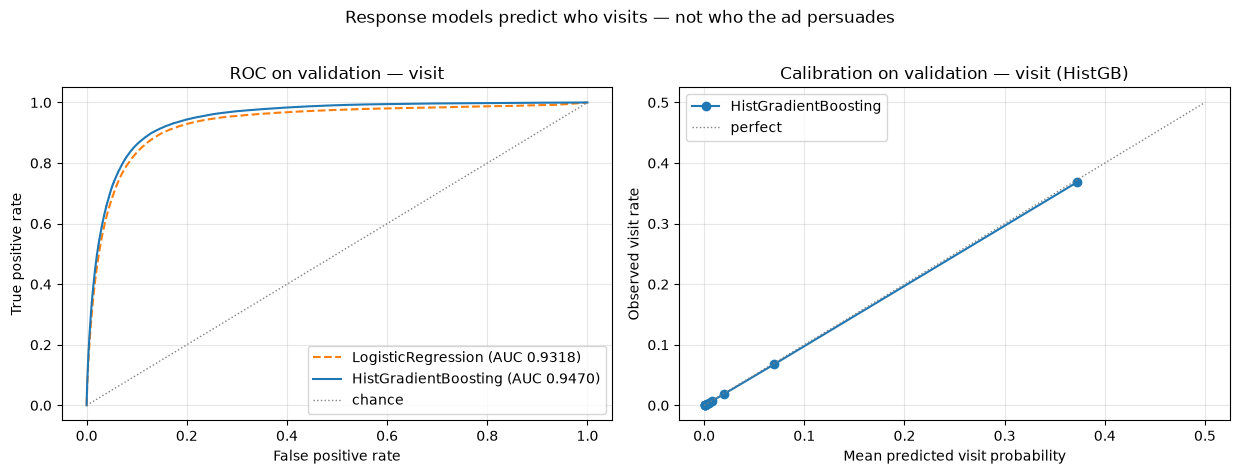

saved e2_response_roc_calibration.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# Panel A: ROC curves, LR vs HistGB (visit, validation)
for p, name, ls, c in [(p_val_lr_visit, "LogisticRegression", "--", "C1"),
                       (p_val_hgb_visit, "HistGradientBoosting", "-", "C0")]:
    fpr, tpr, _ = roc_curve(yval_visit, p)
    axes[0].plot(fpr, tpr, ls, color=c,
                 label=f"{name} (AUC {roc_auc_score(yval_visit, p):.4f})")
axes[0].plot([0, 1], [0, 1], ":", color="grey", lw=1, label="chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC on validation — visit")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

# Panel B: calibration curve, HistGB visit (10 quantile bins)
frac_true, mean_pred = calibration_curve(yval_visit, p_val_hgb_visit,
                                         n_bins=10, strategy="quantile")
axes[1].plot(mean_pred, frac_true, "o-", label="HistGradientBoosting")
axes[1].plot([0, 0.5], [0, 0.5], ":", color="grey", lw=1, label="perfect")
axes[1].set_xlabel("Mean predicted visit probability")
axes[1].set_ylabel("Observed visit rate")
axes[1].set_title("Calibration on validation — visit (HistGB)")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("Response models predict who visits — not who the ad persuades", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "e2_response_roc_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved e2_response_roc_calibration.png")

In [15]:
#Feature importance (permutation importance) for the HistGB visit model

samp = np.random.default_rng(SEED).choice(len(Xval), size=500_000, replace=False)
t0 = time.time()
perm = permutation_importance(hgb_visit, Xval[samp], yval_visit[samp],
                              scoring="neg_log_loss", n_repeats=5,
                              random_state=SEED, n_jobs=1)
print("permutation importance minutes:", round((time.time() - t0) / 60, 2))
imp_df = (pd.DataFrame({"feature": FEATURES,
                        "importance_mean": perm["importances_mean"],
                        "importance_std": perm["importances_std"]})
          .sort_values("importance_mean", ascending=False)
          .reset_index(drop=True))
imp_df.round(6)

permutation importance minutes: 3.52


,feature,importance_mean,importance_std
0,f8,0.074566,0.000212
1,f2,0.028774,0.000291
2,f9,0.007076,0.000068
3,f6,0.001535,0.000036
4,f0,0.001357,0.000054
5,f3,0.000191,0.000015
6,f10,0.000084,0.000009
7,f4,0.000075,0.000003
8,f11,0.000054,0.000005
9,f1,0.000052,0.000003


## Saving Artifacts

In [19]:
metrics_df.to_csv(TAB_DIR / "e2_response_metrics.csv", index=False)
lift_df.to_csv(TAB_DIR / "e2_response_lift_deciles.csv", index=False)
imp_df.to_csv(TAB_DIR / "e2_feature_importance.csv", index=False)
print("tables saved to outputs/tables/")

best_visit = {
    "model": hgb_visit,
    "model_class": "HistGradientBoostingClassifier",
    "hyperparams": {"max_iter": 300, "learning_rate": 0.05,
                    "early_stopping": True, "random_state": SEED},
    "outcome": "visit",
    "fit_population": "train-split treated rows only (row_hash % 1000 < 700, treatment == 1)",
    "features": FEATURES,
    "validation_metrics": {
        r["model"]: {k: float(v) for k, v in r.items()
                     if k not in ("model", "outcome", "rows")}
        for _, r in metrics_df[metrics_df["outcome"] == "visit"].iterrows()
    },
}
joblib.dump(best_visit, INTERIM / "e2_best_visit_model.joblib")
print("saved e2_best_visit_model.joblib")
print("total notebook minutes:", round((time.time() - T0) / 60, 2))


tables saved to outputs/tables/
saved e2_best_visit_model.joblib
total notebook minutes: 14.61


## Does predicting conversion tell us who to target?

**No — not by itself.** P(Y=1 | X) mixes two very different kinds of users: those who would visit/buy *anyway* (**sure things** — the ad spends budget on response it did not cause) and those moved *by* the ad (**persuadables** — the only users the campaign can win). A response score ranks the two together, and its top decile can even be dominated by sure things.

The relevant targeting quantity is a *difference of potential outcomes* — P(Y=1|X, treat) vs P(Y=1|X, control) — not a single conditional prediction.

### Single-feature AUC (context for the headline model quality)

The 0.947 twelve-feature AUC is **not an achievement to headline**: `f8` alone reaches 0.926 and `f9` alone 0.893 o validation. The features very likely encode prior engagement / user-history variables 

In [20]:
from sklearn.metrics import roc_auc_score


cols_needed = [f"f{i}" for i in range(12)] + ["visit", "row_hash"]
d = pd.read_parquet(PARQUET, columns=cols_needed)
vmask_s = (d["row_hash"] % 1000 >= 700) & (d["row_hash"] % 1000 < 850)
d = d[vmask_s].reset_index(drop=True)
d = d.iloc[np.random.default_rng(42).choice(len(d), 2_000_000, replace=False)]
ys = d["visit"].to_numpy()
rows = []
for c in [f"f{i}" for i in range(12)]:
    a = roc_auc_score(ys, d[c].to_numpy())
    rows.append(dict(feature=c, auc_best_orientation=round(max(a, 1 - a), 4)))
sf_auc_tab = pd.DataFrame(rows).sort_values("auc_best_orientation", ascending=False)
sf_auc_tab.to_csv(TAB_DIR / "e2_single_feature_auc.csv", index=False)
del d
sf_auc_tab

,feature,auc_best_orientation
8,f8,0.9257
9,f9,0.8934
3,f3,0.6683
0,f0,0.6598
4,f4,0.6307
10,f10,0.6284
2,f2,0.6123
6,f6,0.6082
5,f5,0.5651
11,f11,0.5646
